# Tutorial 1: Parameterizing spikes with `spikewise`

`spikewise` describes each action potential with a small set of physiologically interpretable features, instead of treating it as a binary event. This tutorial fits the spikes in one recording, shows what the features mean, and covers the settings you are most likely to change.

`spikewise` was developed for, and is described in:

> Martin-Burgos, B., Juavinett, A., Riviere, P., Hammonds, R., & Voytek, B. (2026). *Action potential waveforms are state-dependent*. bioRxiv. https://www.biorxiv.org/content/10.64898/2026.09.15.751814v1

Please cite it if you use `spikewise`.

The example data (`data/example_recordings.npz`, 2.6 MB) are short excerpts of two open datasets, so the tutorial runs without downloading anything:
- **pvc-6** (Berg, 2014; CRCNS): whole-cell patch clamp recordings from an SST+ interneuron in mouse visual cortex, driven with constant, ramp and pink noise current. 14 sweeps, voltage at 50 kHz and injected current at 10 kHz.
- **spe-1** (Marques-Smith et al., 2018; CRCNS): 5 s of a juxtacellular recording from a pyramidal neuron in rat cortex, at about 50 kHz.

`data/build_tutorial_data.py` shows how the excerpts were made.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from spikewise.patch.fit import Spike

In [2]:
d = np.load('data/example_recordings.npz')
fs, current_fs = int(d['voltage_fs']), int(d['current_fs'])

def voltage(key):   # membrane voltage (mV) of one sweep
    return d[f'{key}_voltage'] / d['voltage_scale']

def current(key):   # injected current (pA) of one sweep
    return d[f'{key}_current'] / d['current_scale']

sweeps = pd.DataFrame({'key': d['sweep_keys'], 'sweep': d['sweep_numbers'], 'stim_type': d['stim_types']})
sweeps

,key,sweep,stim_type
0,sweep11,11,constant
1,sweep20,20,constant
2,sweep0,0,ramp
3,sweep1,1,ramp
4,sweep13,13,pink
5,sweep14,14,pink
6,sweep15,15,pink
7,sweep17,17,pink
8,sweep18,18,pink
9,sweep19,19,pink


## 1. A recording

Sweep 20 is a 3 s step of constant current. The neuron fires a handful of spikes.

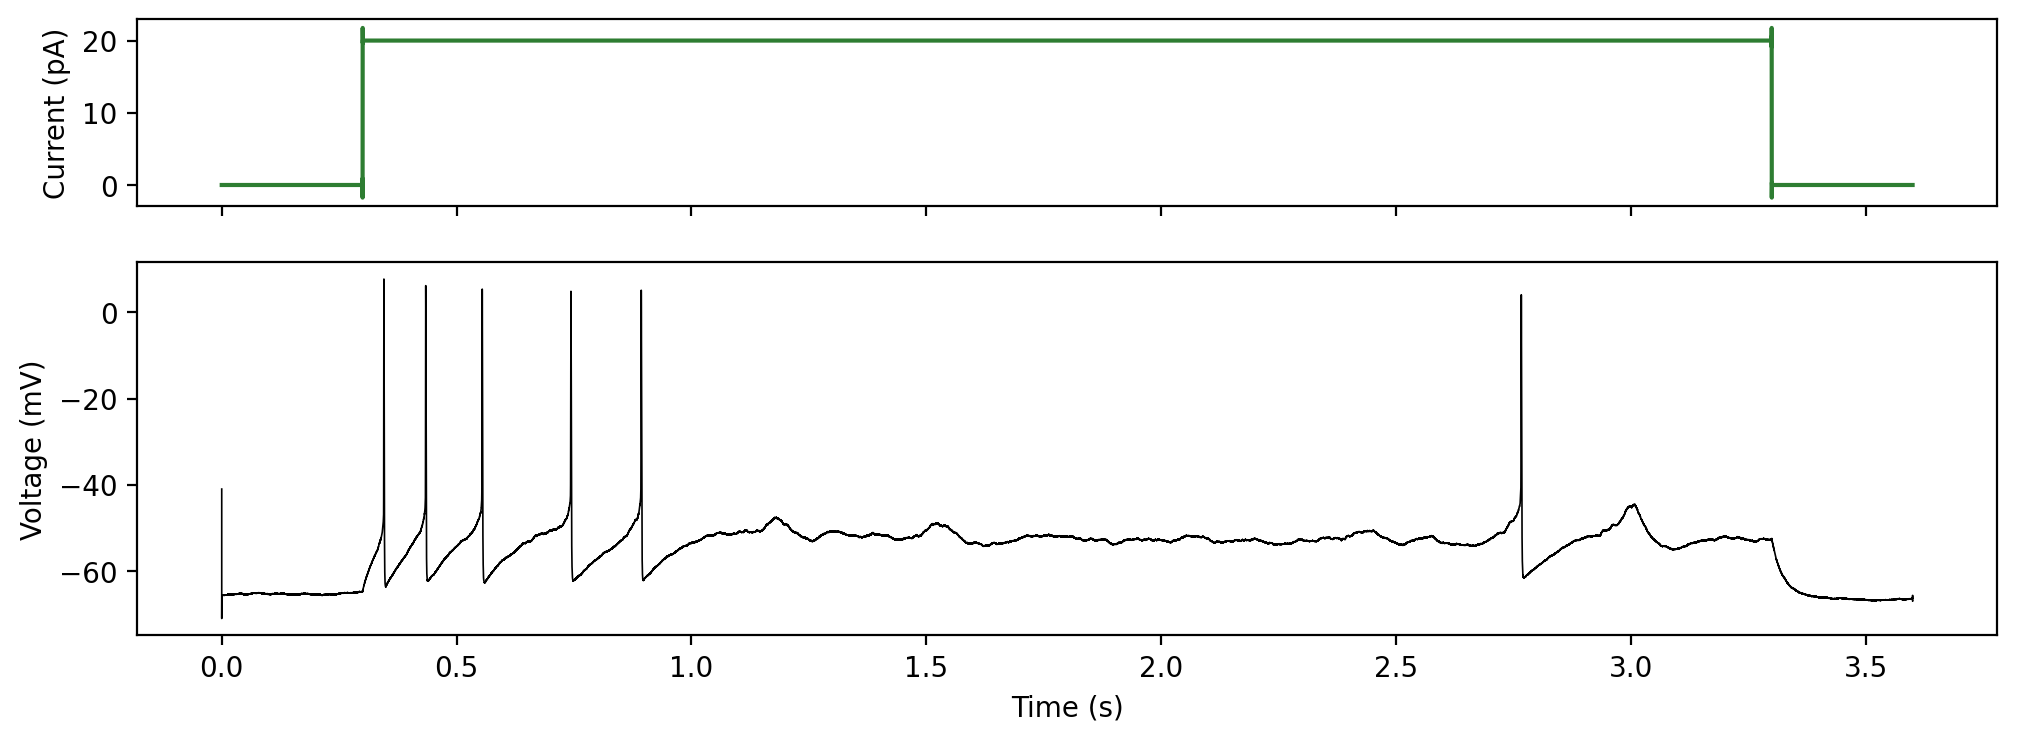

In [3]:
sig = voltage('sweep20')
t = np.arange(len(sig)) / fs

fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True, gridspec_kw={'height_ratios': [1, 2]})
axes[0].plot(np.arange(len(current('sweep20'))) / current_fs, current('sweep20'), color='#2E7D32')
axes[0].set_ylabel('Current (pA)')
axes[1].plot(t, sig, color='k', lw=0.6)
axes[1].set_ylabel('Voltage (mV)')
axes[1].set_xlabel('Time (s)')
plt.show()

## 2. Fit the spikes

Create a `Spike` object with your settings, then call `.fit(signal, sampling_rate)`. `spikewise` finds every spike that crosses `thresh_amp`, cuts a window around it, and fits it.

In [4]:
sp = Spike(thresh_amp=-10, window_length=(5., 5.), smooth_frac=.008, pre_inflection_ms=0.5)
sp.fit(sig, fs)
print(f'{sp.n_spikes} spikes found')

6 spikes found


Each spike is split into three parts:
- **ramp**: a straight line fit to the slow depolarization before the spike, which ends at the **inflection** point where the spike takes off;
- **peak**: measured directly on the waveform (the **rise** and **decay** points sit halfway between the inflection voltage and the peak);
- **repolarization**: an exponential fit to the voltage coming back down.

`.plot()` shows the data, the fits (dashed) and these control points for any spike.

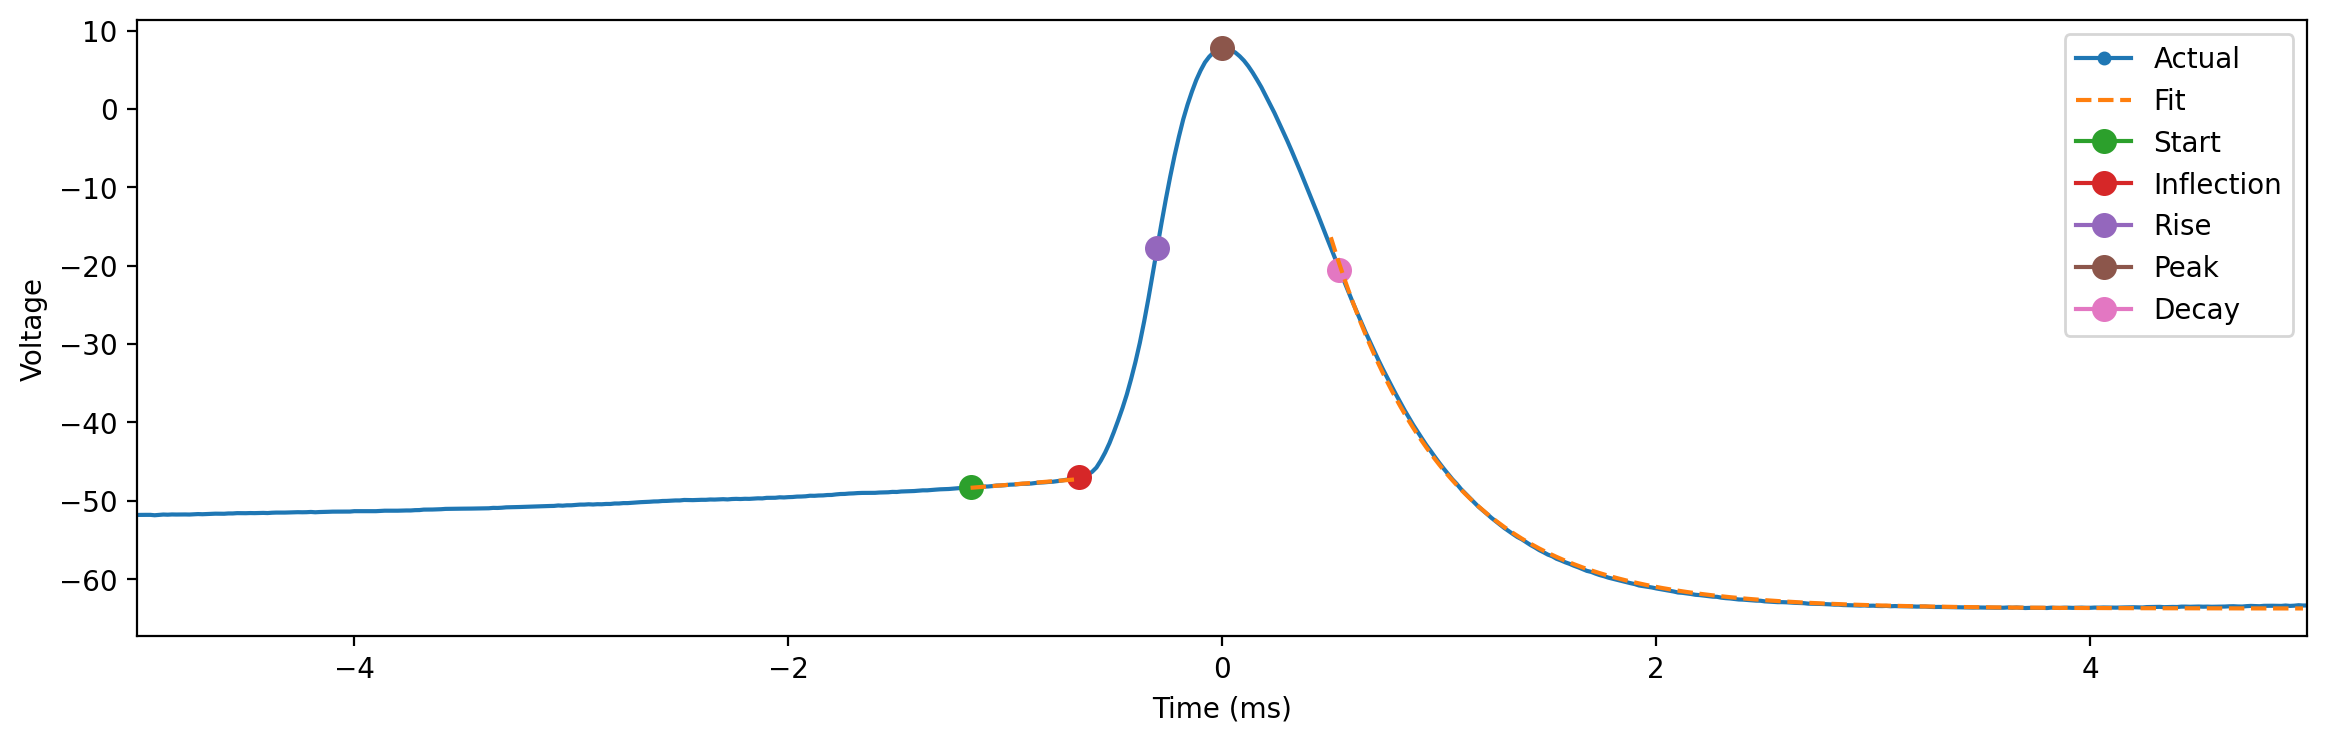

In [5]:
sp.plot(inds=0, show_points=True)
plt.show()

`.plot_summary()` overlays all spikes: the full waveforms, then just the ramp fits and just the exponential fits.

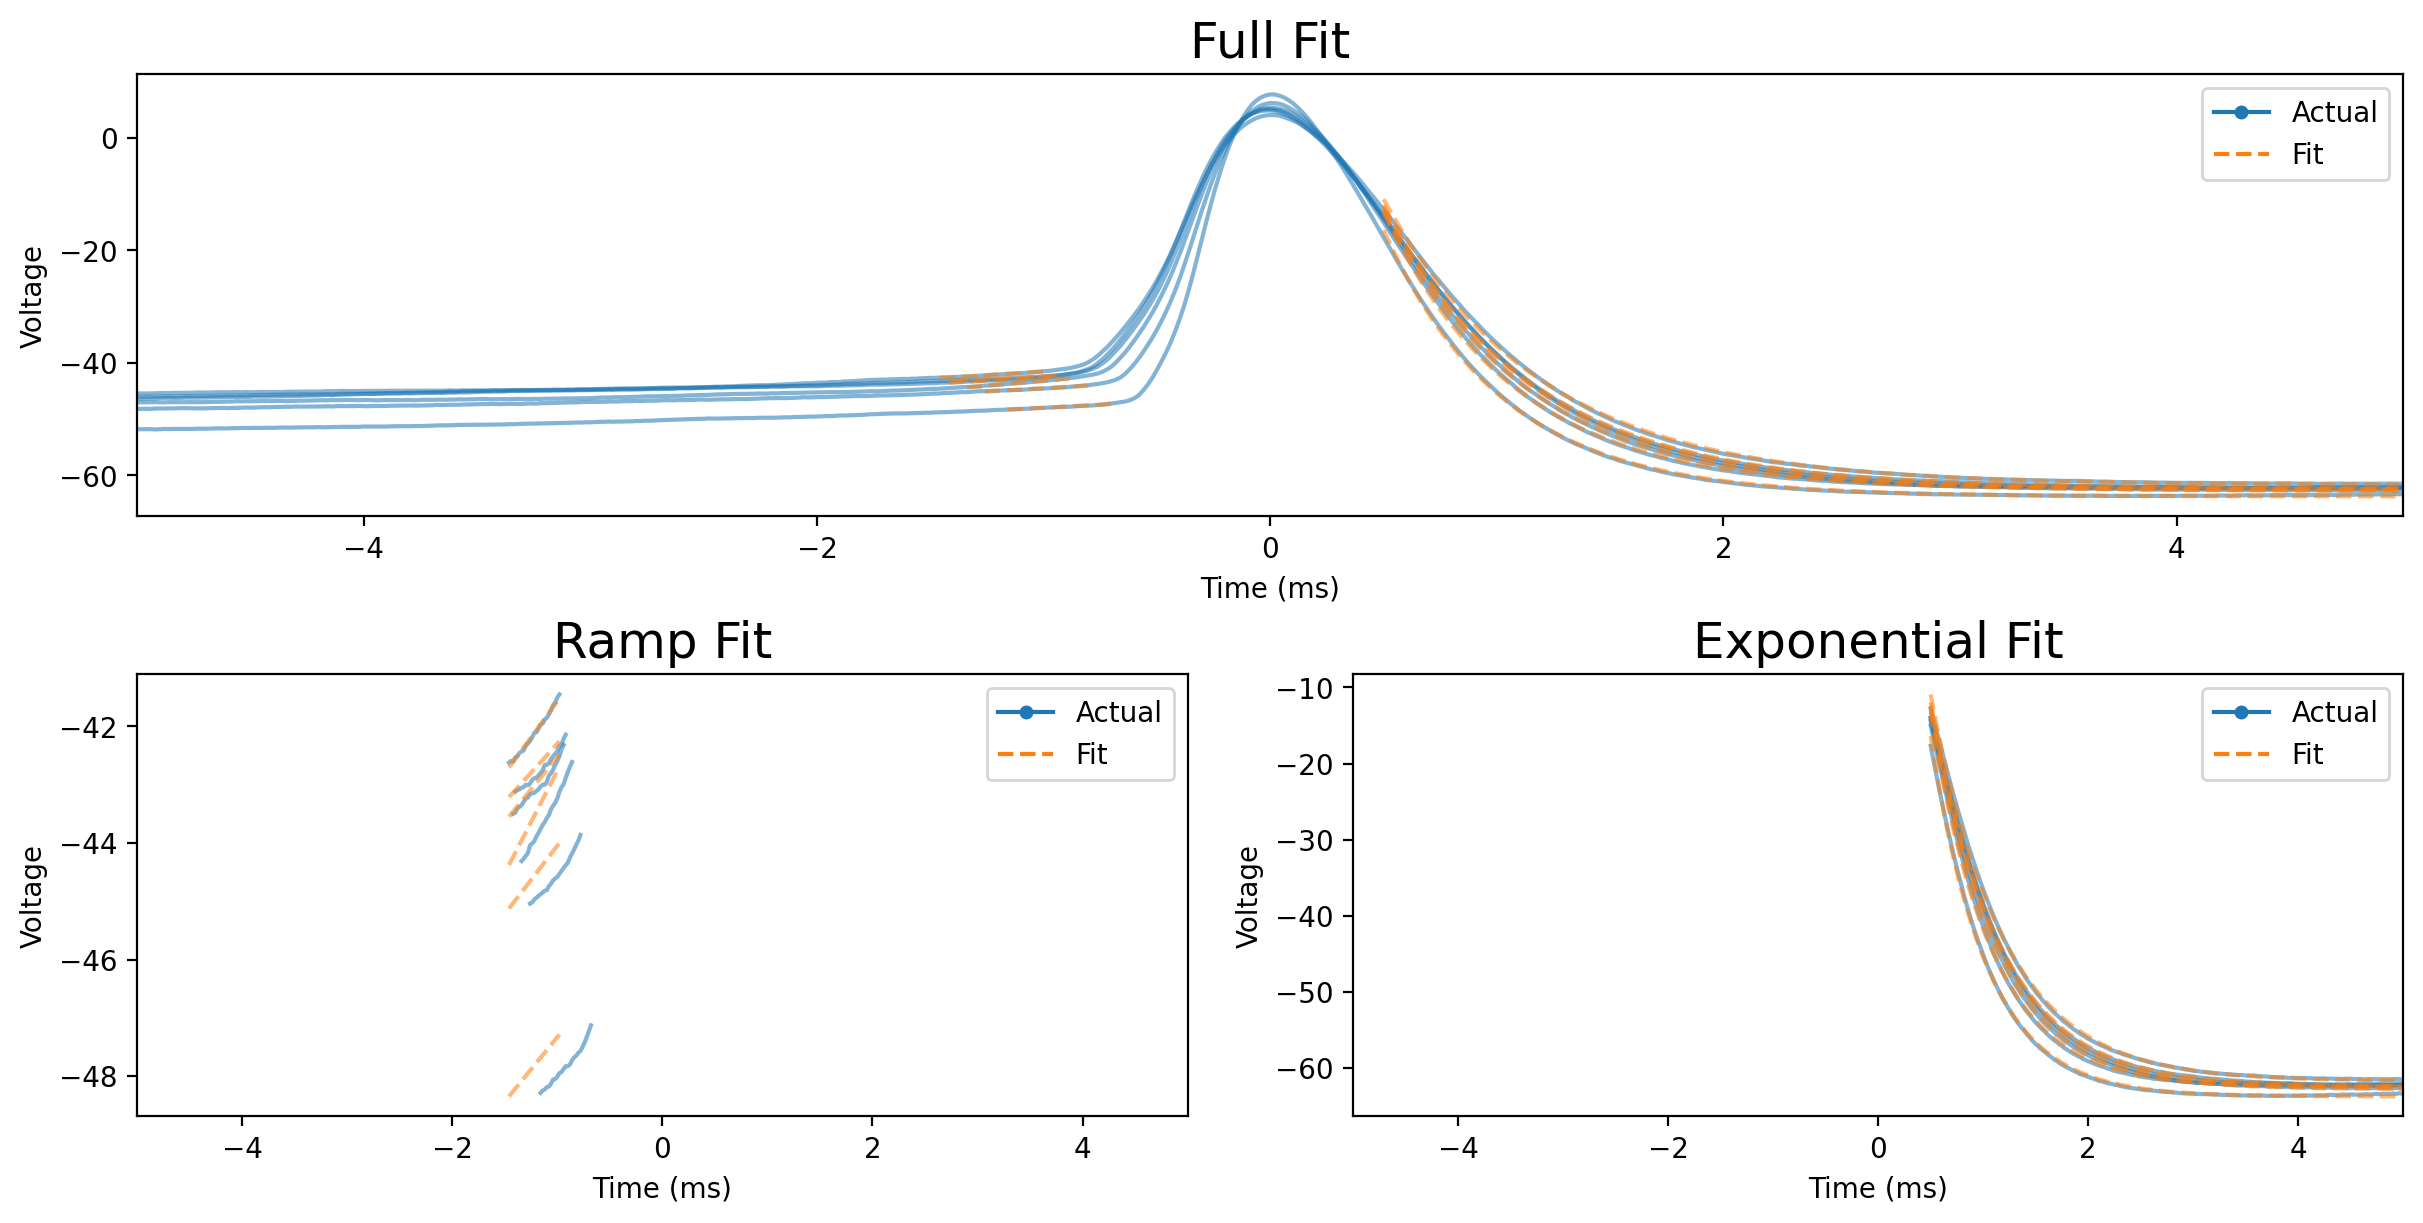

In [6]:
sp.plot_summary()
plt.show()

## 3. The feature table

`sp.df_features` has one row per spike and one column per feature.

| feature | what it measures |
|---|---|
| `ramp_amp` | slope of the pre-spike ramp |
| `inflection_time` | time from the inflection to the peak (ms); larger means an earlier take-off |
| `inflection_amp` | voltage at the inflection |
| `peak_amp` | voltage at the peak |
| `peak_width` | time between the rise and decay points, halfway up the spike (ms) |
| `peak_sharpness` | mean drop from the peak to the points 0.1 ms on either side (higher = pointier) |
| `exp_lambda` | decay rate of the repolarization |
| `exp_const` | voltage the repolarization decays toward |
| `isi`, `isi_prev` | time to the next and from the previous spike (ms) |
| `n_spikes_50ms`, `n_spikes_200ms` | number of spikes in the preceding 50 or 200 ms |
| `r_squared_ramp`, `r_squared_exp` | how well the ramp and exponential fits match the data |

In [7]:
sp.df_features.round(2)

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,isi_prev,n_spikes_50ms,n_spikes_200ms,r_squared_ramp,r_squared_exp
0,2.21,0.66,-47.13,7.72,0.84,2.18,1.90,-63.75,89.06,NaN,0,0,0.97,1.0
1,2.34,0.76,-43.86,6.19,0.92,1.67,1.73,-62.52,120.26,89.06,0,1,0.97,1.0
2,3.51,0.84,-42.61,5.38,0.96,1.34,1.59,-62.80,188.90,120.26,0,1,0.99,1.0
3,2.22,0.92,-42.32,4.87,1.00,1.22,1.50,-62.42,149.66,188.90,0,1,0.96,1.0
4,1.99,0.90,-42.14,5.12,0.98,1.33,1.55,-62.48,1873.62,149.66,0,1,0.97,1.0
5,2.47,0.96,-41.45,4.07,1.02,1.20,1.44,-61.72,NaN,1873.62,0,0,0.99,1.0


`sp.df_indices` gives the sample index of every control point, useful for lining spikes up with other signals (see Tutorial 3).

In [8]:
sp.df_indices.head()

,ramp_start,inflection,rise,peak,decay,exp_start,exp_end
0,17207,17232,17250,17265,17292,17290,17515
1,21655,21680,21701,21718,21747,21743,21968
2,27664,27689,27712,27731,27760,27756,27981
3,37105,37130,37156,37176,37206,37201,37426
4,44589,44614,44640,44659,44689,44684,44909


## 4. Keep well-fit spikes

Not every spike fits cleanly, especially in noisy recordings. `filter_features` drops spikes below a fit quality threshold. With `inplace=False` it returns a new, filtered object and leaves the original untouched. By default it also converts the ISIs to log ISIs and drops the R² columns. This recording is clean, so every spike passes; noisier recordings (for example juxtacellular or extracellular ones) typically lose more.

In [9]:
sp_good = sp.filter_features(min_r2_ramp=0.5, min_r2_exp=0.5, inplace=False)
print(f'{sp_good.n_spikes} of {sp.n_spikes} spikes kept')
sp_good.df_features.round(2).head()

6 of 6 spikes kept


,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,n_spikes_50ms,n_spikes_200ms,log_isi,log_isi_prev
0,2.21,0.66,-47.13,7.72,0.84,2.18,1.90,-63.75,0,0,1.95,NaN
1,2.34,0.76,-43.86,6.19,0.92,1.67,1.73,-62.52,0,1,2.08,1.95
2,3.51,0.84,-42.61,5.38,0.96,1.34,1.59,-62.80,0,1,2.28,2.08
3,2.22,0.92,-42.32,4.87,1.00,1.22,1.50,-62.42,0,1,2.18,2.28
4,1.99,0.90,-42.14,5.12,0.98,1.33,1.55,-62.48,0,1,3.27,2.18


## 5. Settings you are most likely to change

| setting | what it does | tip |
|---|---|---|
| `thresh_amp` | detection threshold, in signal units | set it between the baseline and the spike peaks |
| `window_length` | ms kept before and after each peak | long enough to include the ramp and the decay |
| `smooth_frac` | fraction of each window used to smooth before finding control points | increase for noisier recordings |
| `pre_inflection_ms` | how far before the inflection the ramp fit starts | shorter for fast-spiking cells |
| `flip_signal` (in `.fit`) | inverts the signal before fitting | for recordings where spikes point down |
| `n_jobs` (in `.fit`) | number of parallel workers | keep at 1 for short recordings |

### Recordings where spikes point down

In juxtacellular (and many extracellular) recordings, spikes are negative-going. Detection looks for peaks above `thresh_amp`, so nothing is found until the signal is flipped.

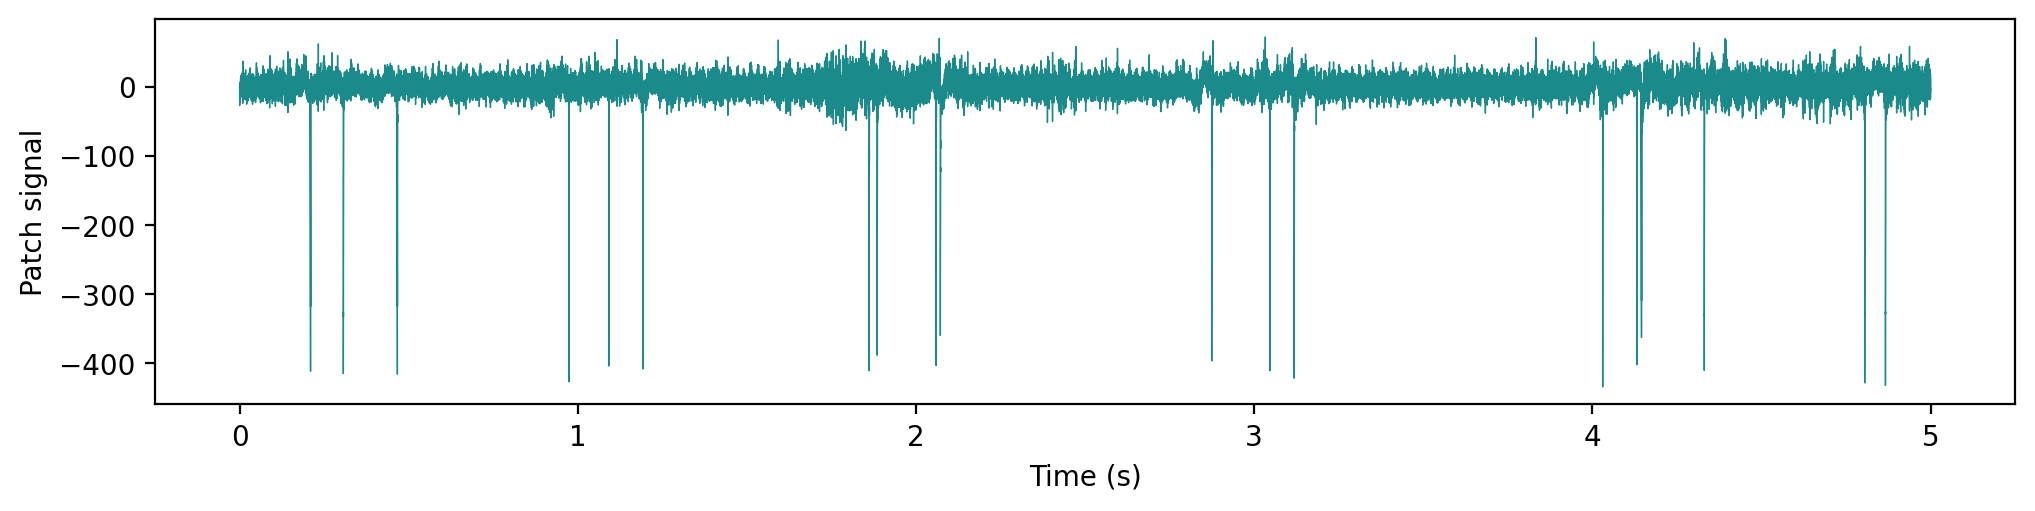

/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikewise/spikewise/patch/fit/fit.py:389: UserWarning: No spikes detected.
  warnings.warn('No spikes detected.')


without flipping: 0 spikes
with flip_signal=True: 19 spikes


In [10]:
juxta = d['spe1_juxta'] / d['spe1_scale']
juxta_fs = float(d['spe1_fs'])

plt.figure(figsize=(12, 2.5))
plt.plot(np.arange(len(juxta)) / juxta_fs, juxta, color='#1A8A8A', lw=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Patch signal')
plt.show()

sp_juxta = Spike(thresh_amp=137.2, window_length=(5., 5.), smooth_frac=.01)
sp_juxta.fit(juxta, juxta_fs)
print('without flipping:', sp_juxta.n_spikes or 0, 'spikes')

sp_juxta = Spike(thresh_amp=137.2, window_length=(5., 5.), smooth_frac=.01)
sp_juxta.fit(juxta, juxta_fs, flip_signal=True)
print('with flip_signal=True:', sp_juxta.n_spikes, 'spikes')

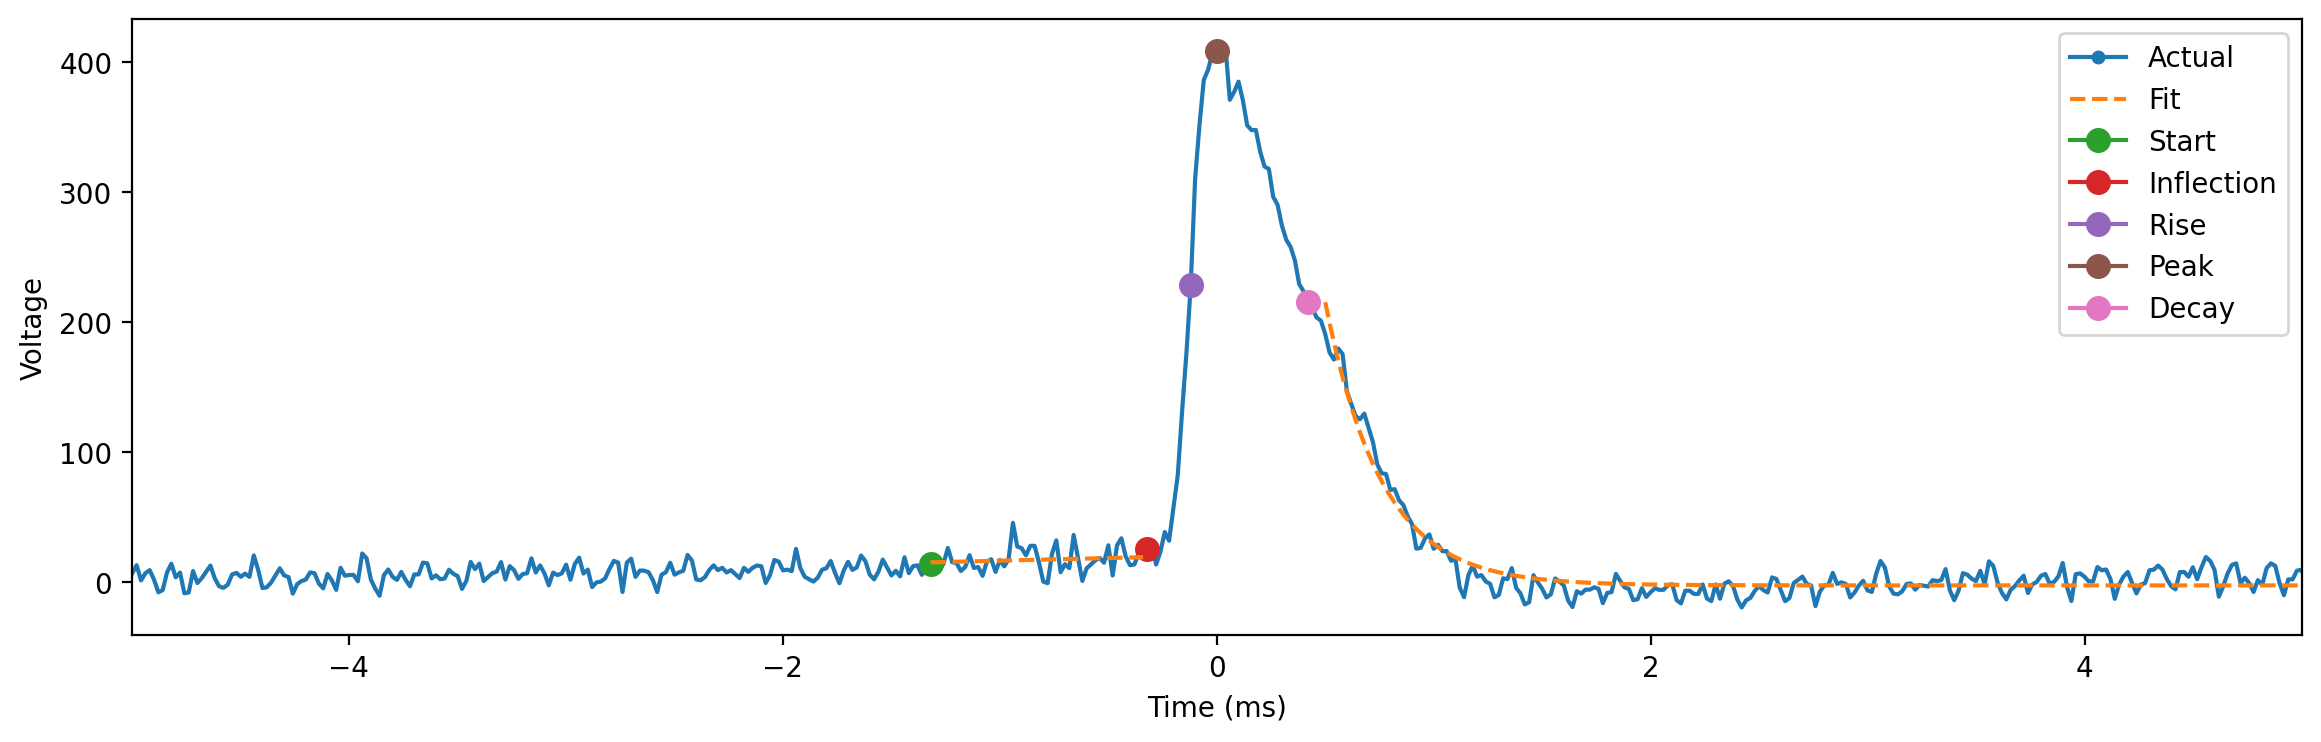

In [11]:
sp_juxta.plot(inds=0, show_points=True)
plt.show()

Next: [Tutorial 2](02_many_recordings.ipynb) fits many sweeps at once and compares features across conditions.